# Feature engineering and selection

Building a feature set to predict campaign response - demographics,
spending by category, purchase channel mix, and engagement (recency,
web visits). Ranking candidates before committing to a model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

customers = pd.read_csv('outputs/customers_clean.csv', parse_dates = ['Dt_Customer'])

customers['Education_enc'] = LabelEncoder().fit_transform(customers['Education'])
customers['Marital_enc'] = LabelEncoder().fit_transform(customers['Marital_Status'])

feature_cols = [
    'Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'TotalSpend',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Education_enc', 'Marital_enc',
]
X = customers[feature_cols]
y = customers['Response']
X.shape

(2216, 13)

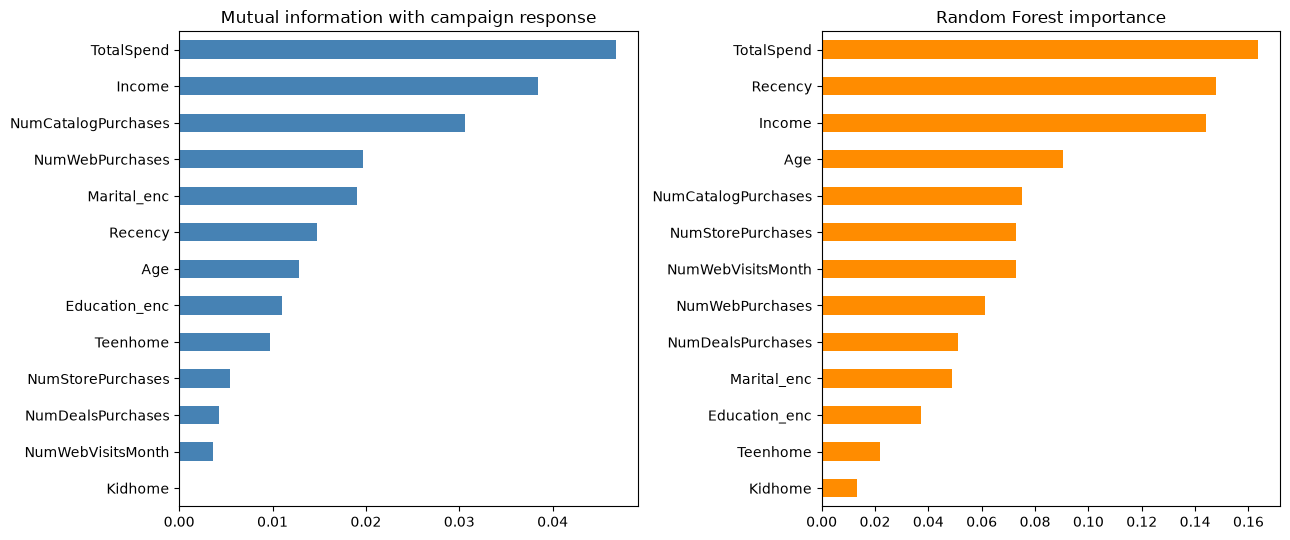

In [2]:
mi_scores = mutual_info_classif(X, y, random_state = 42)
mi_series = pd.Series(mi_scores, index = feature_cols).sort_values(ascending = False)

rf = RandomForestClassifier(n_estimators = 300, random_state = 42, n_jobs = -1)
rf.fit(X, y)
rf_series = pd.Series(rf.feature_importances_, index = feature_cols).sort_values(ascending = False)

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5))
mi_series.plot.barh(ax = axes[0], color = 'steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Mutual information with campaign response')

rf_series.plot.barh(ax = axes[1], color = 'darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest importance')

plt.tight_layout()
plt.savefig('outputs/feature_selection.png', dpi = 120)
plt.show()

`TotalSpend` and `Income` rank near the top by both methods, big spenders respond more. `Recency` (days since last purchase) is Random Forest's #2 feature but ranks lower by mutual information, while `NumCatalogPurchases` shows the opposite pattern, another case where univariate and combined-feature importance don't fully agree, and both views are worth keeping. `Education_enc` ranks well down the list in both, despite showing up as statistically significant in the previous notebook, a reminder that "statistically significant" and "strongly predictive" aren't the same claim.

In [3]:
import json
import os

os.makedirs('outputs', exist_ok = True)
with open('outputs/feature_list.json', 'w') as f:
    json.dump(feature_cols, f, indent = 2)

mi_series.to_dict()

{'TotalSpend': 0.04674612364430697,
 'Income': 0.03847304962536069,
 'NumCatalogPurchases': 0.030605269397998125,
 'NumWebPurchases': 0.019640484877069264,
 'Marital_enc': 0.018996592823863345,
 'Recency': 0.014709738386636584,
 'Age': 0.012817574255389319,
 'Education_enc': 0.010978278483155135,
 'Teenhome': 0.009745304009832312,
 'NumStorePurchases': 0.005430188314940354,
 'NumDealsPurchases': 0.004308482837341865,
 'NumWebVisitsMonth': 0.0036529013460517845,
 'Kidhome': 0.0}